Mounted at /content/drive
DATASET INFORMATION
Shape : (21263, 82)

Total Features : 81


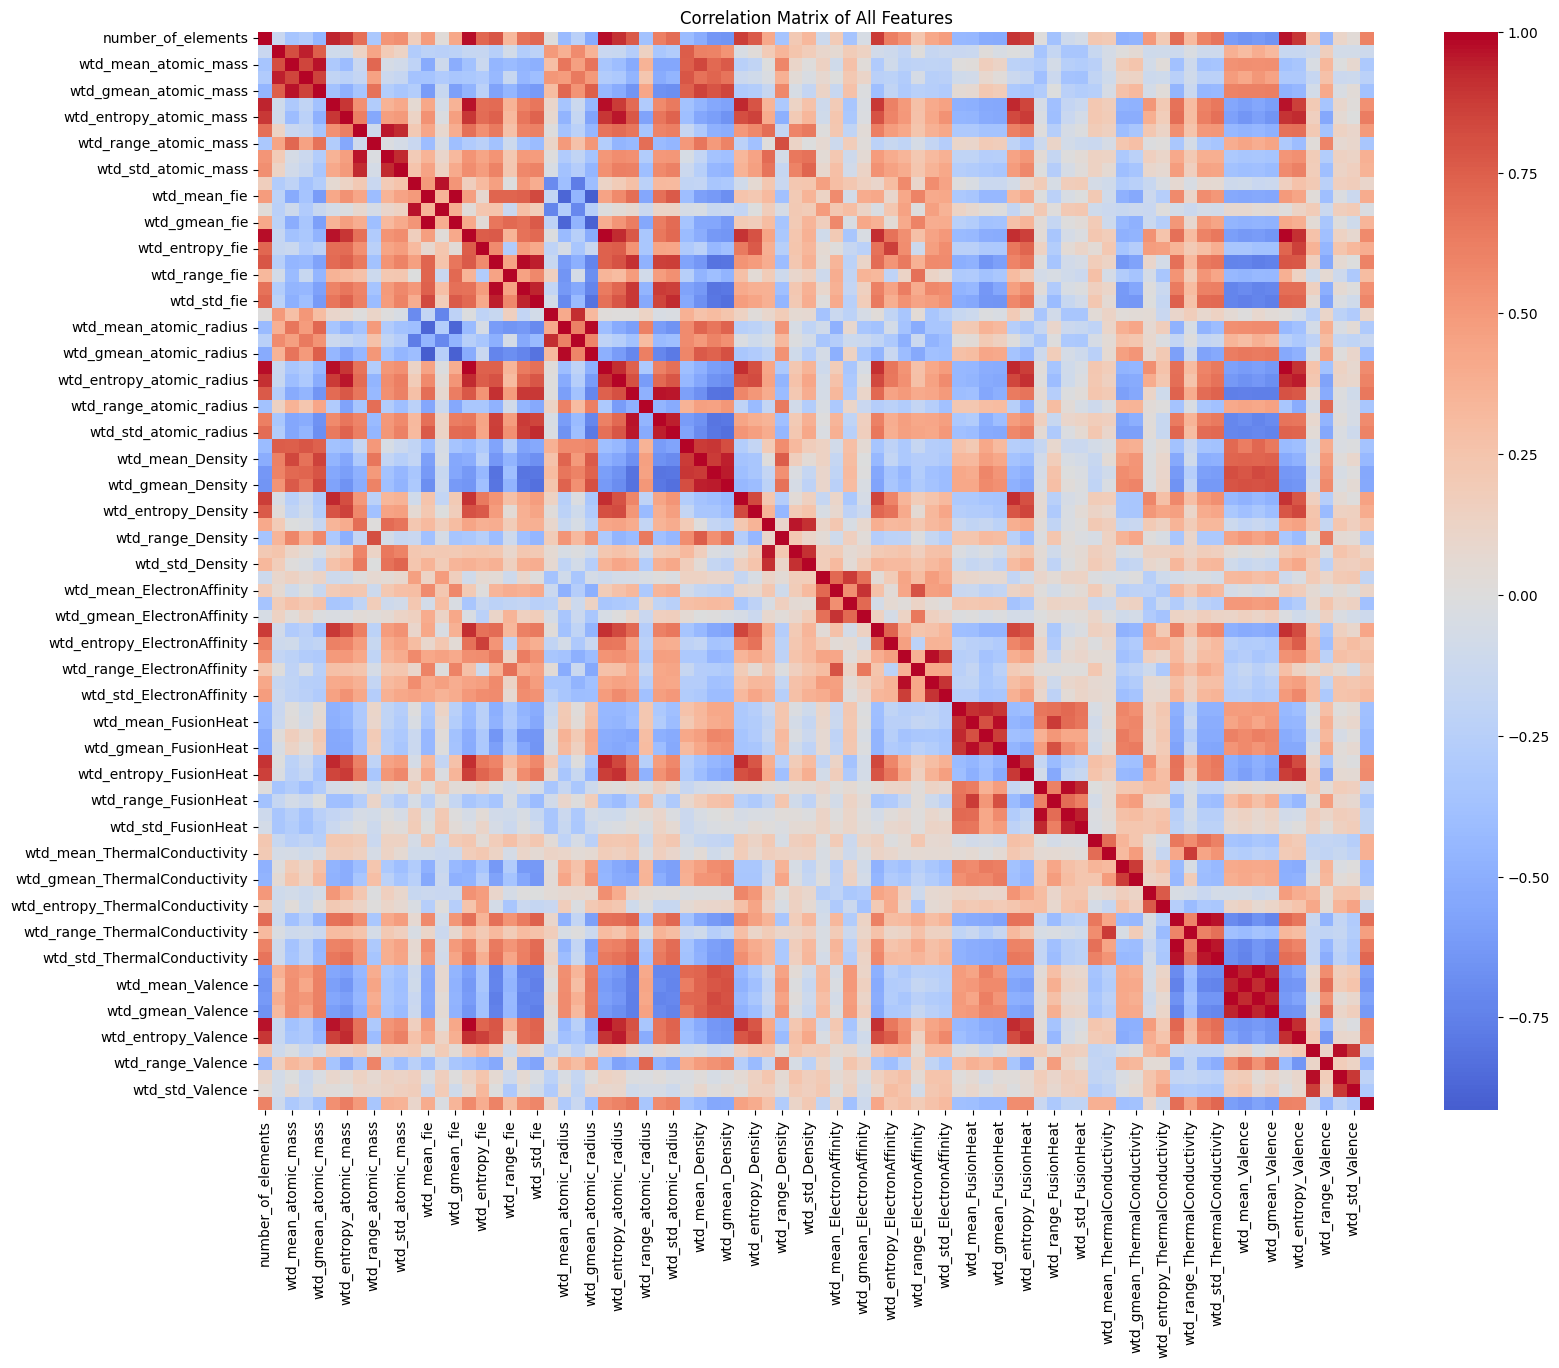


Train Shape      : (17010, 81)
Validation Shape : (2126, 81)
Test Shape       : (2127, 81)


VALIDATION RESULTS
Validation MAE   : 13.4394
Validation MSE   : 307.7834
Validation RMSE  : 17.5438
Validation R²    : 0.7368


TEST RESULTS
Test MAE         : 12.9818
Test MSE         : 296.2344
Test RMSE        : 17.2115
Test R²          : 0.7384
Adjusted R²      : 0.7280
MAPE             : 6.1964


FINAL RESULT TABLE
               Model  Validation RMSE  Validation R²  Test RMSE  Test R²
0  Linear Regression          17.5438         0.7368    17.2115   0.7384


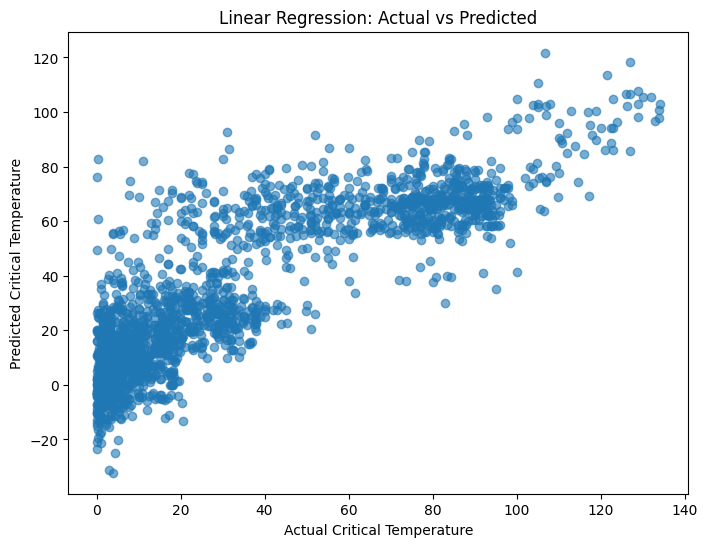

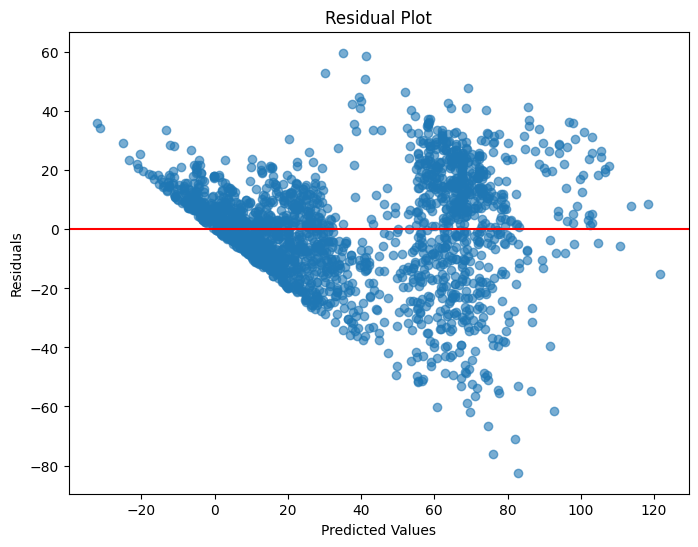



FEATURE IMPORTANCE
                            Feature  Coefficient  Absolute_Coefficient
24          wtd_gmean_atomic_radius   -89.139308             89.139308
22           wtd_mean_atomic_radius    83.170114             83.170114
15                      entropy_fie   -38.405674             38.405674
2              wtd_mean_atomic_mass   -32.204229             32.204229
74                wtd_gmean_Valence   -31.421406             31.421406
..                              ...          ...                   ...
8             wtd_range_atomic_mass     0.996289              0.996289
78                wtd_range_Valence    -0.623665              0.623665
38                wtd_range_Density    -0.521575              0.521575
23              gmean_atomic_radius    -0.457934              0.457934
66  wtd_entropy_ThermalConductivity     0.281668              0.281668

[81 rows x 3 columns]


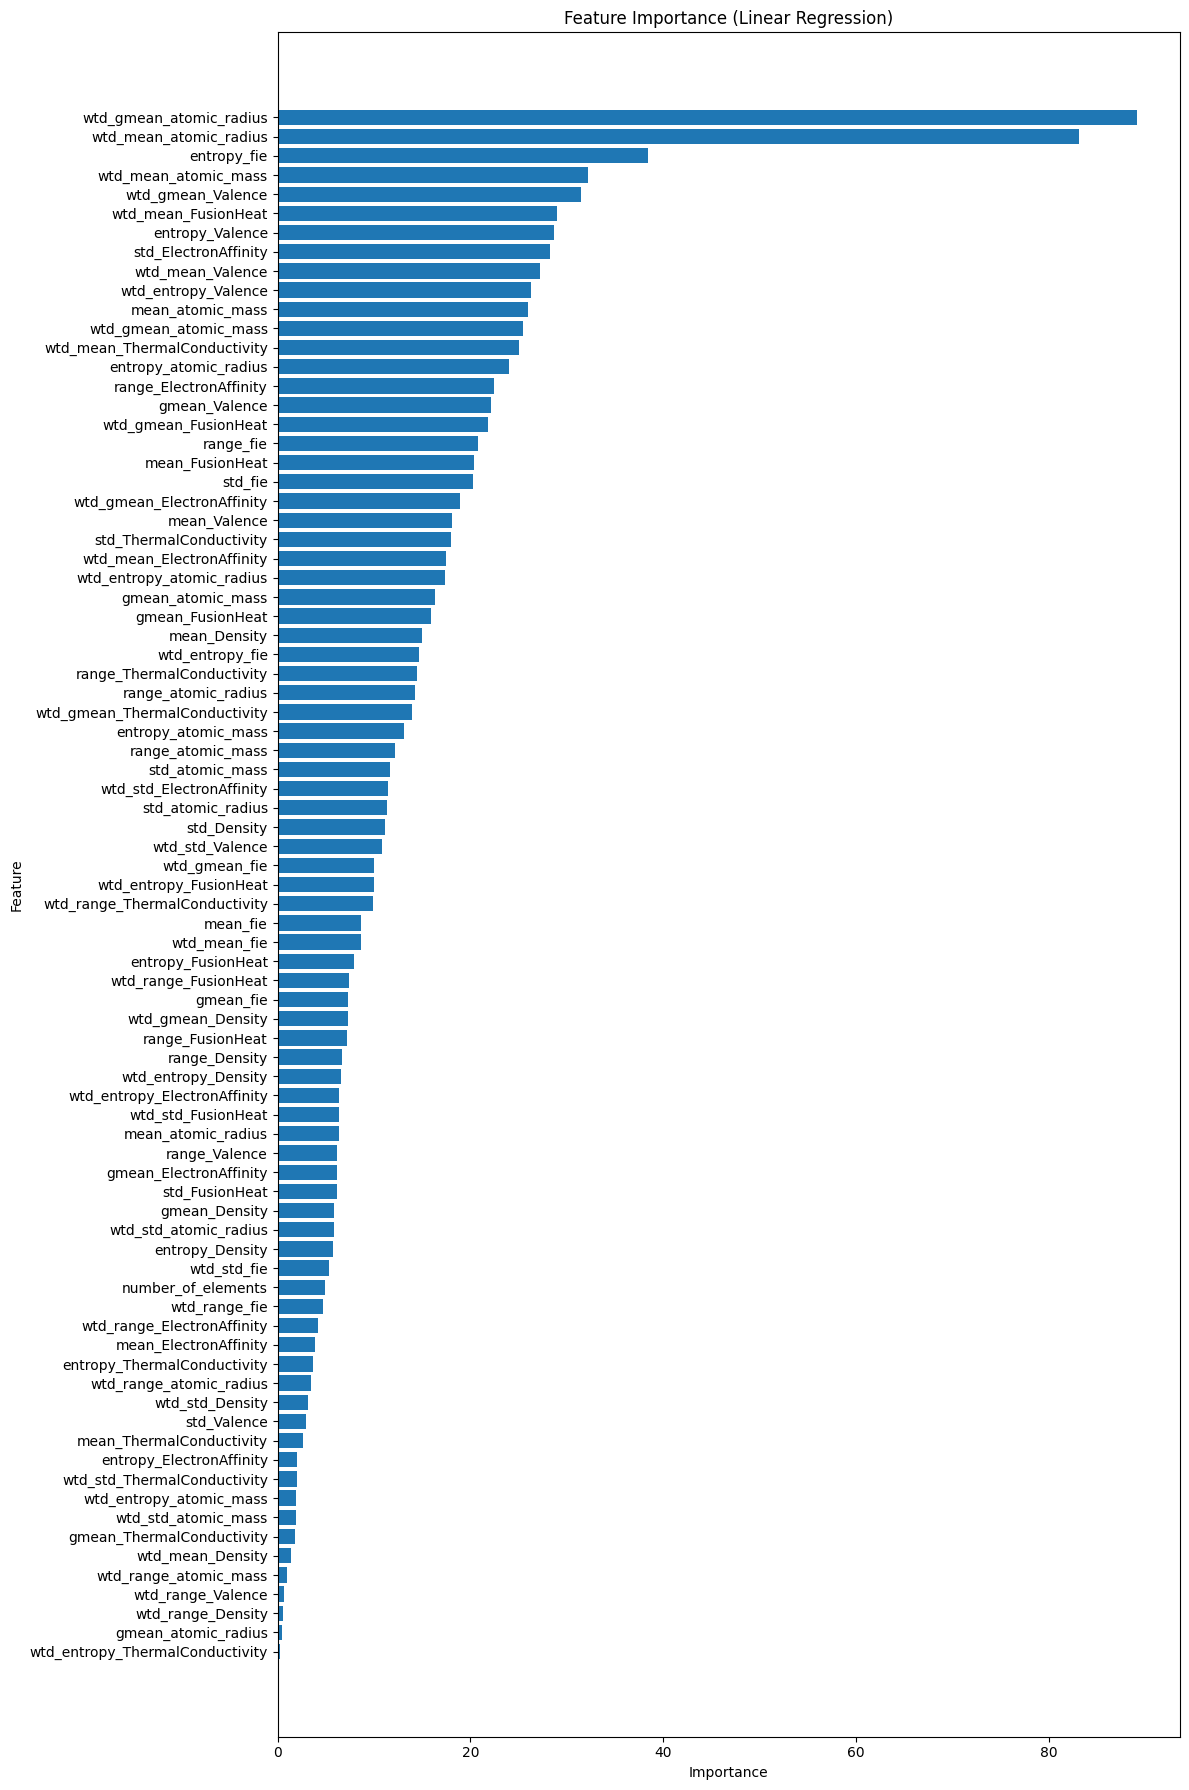



TOP 10 IMPORTANT FEATURES
                    Feature  Coefficient  Absolute_Coefficient
24  wtd_gmean_atomic_radius   -89.139308             89.139308
22   wtd_mean_atomic_radius    83.170114             83.170114
15              entropy_fie   -38.405674             38.405674
2      wtd_mean_atomic_mass   -32.204229             32.204229
74        wtd_gmean_Valence   -31.421406             31.421406
52      wtd_mean_FusionHeat   -28.982422             28.982422
75          entropy_Valence    28.620624             28.620624
49     std_ElectronAffinity    28.251291             28.251291
72         wtd_mean_Valence    27.257138             27.257138
76      wtd_entropy_Valence   -26.292397             26.292397


In [2]:
# ============================================================
# SUPERCONDUCTOR CRITICAL TEMPERATURE PREDICTION
# LINEAR REGRESSION
# GOOGLE DRIVE VERSION
# ============================================================

# ============================================================
# 1. CONNECT GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

# ============================================================
# 3. LOAD DATASET
# ============================================================

file_path = "/content/drive/MyDrive/train.csv"

df = pd.read_csv(file_path)

print("="*60)
print("DATASET INFORMATION")
print("="*60)

print("Shape :", df.shape)

# ============================================================
# 4. INPUT AND OUTPUT
# ============================================================

target = "critical_temp"

X = df.drop(columns=[target])
y = df[target]

print("\nTotal Features :", X.shape[1])

# ============================================================
# 5. HANDLE MISSING VALUES
# ============================================================

X = X.fillna(X.median())
y = y.fillna(y.median())

# ============================================================
# 6. CORRELATION MATRIX
# ============================================================

plt.figure(figsize=(18,14))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of All Features")
plt.show()

# ============================================================
# 7. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("\nTrain Shape      :", X_train.shape)
print("Validation Shape :", X_val.shape)
print("Test Shape       :", X_test.shape)

# ============================================================
# 8. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

# ============================================================
# 9. LINEAR REGRESSION MODEL
# ============================================================

model = LinearRegression()

model.fit(
    X_train_scaled,
    y_train
)

# ============================================================
# 10. VALIDATION PREDICTIONS
# ============================================================

y_val_pred = model.predict(X_val_scaled)

val_mae = mean_absolute_error(y_val, y_val_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
val_rmse = np.sqrt(val_mse)
val_r2 = r2_score(y_val, y_val_pred)

# ============================================================
# 11. TEST PREDICTIONS
# ============================================================

y_test_pred = model.predict(X_test_scaled)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

test_mape = mean_absolute_percentage_error(
    y_test,
    y_test_pred
)

# ============================================================
# 12. ADJUSTED R²
# ============================================================

n = len(y_test)
p = X_test.shape[1]

adj_r2 = 1 - (
    ((1 - test_r2) * (n - 1))
    /
    (n - p - 1)
)

# ============================================================
# 13. RESULTS
# ============================================================

print("\n")
print("="*60)
print("VALIDATION RESULTS")
print("="*60)

print(f"Validation MAE   : {val_mae:.4f}")
print(f"Validation MSE   : {val_mse:.4f}")
print(f"Validation RMSE  : {val_rmse:.4f}")
print(f"Validation R²    : {val_r2:.4f}")

print("\n")
print("="*60)
print("TEST RESULTS")
print("="*60)

print(f"Test MAE         : {test_mae:.4f}")
print(f"Test MSE         : {test_mse:.4f}")
print(f"Test RMSE        : {test_rmse:.4f}")
print(f"Test R²          : {test_r2:.4f}")
print(f"Adjusted R²      : {adj_r2:.4f}")
print(f"MAPE             : {test_mape:.4f}")

# ============================================================
# 14. FINAL TABLE
# ============================================================

results = pd.DataFrame({
    "Model":["Linear Regression"],
    "Validation RMSE":[round(val_rmse,4)],
    "Validation R²":[round(val_r2,4)],
    "Test RMSE":[round(test_rmse,4)],
    "Test R²":[round(test_r2,4)]
})

print("\n")
print("="*70)
print("FINAL RESULT TABLE")
print("="*70)

print(results)

# ============================================================
# 15. ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.6
)

plt.xlabel("Actual Critical Temperature")
plt.ylabel("Predicted Critical Temperature")

plt.title(
    "Linear Regression: Actual vs Predicted"
)

plt.show()

# ============================================================
# 16. RESIDUAL PLOT
# ============================================================

residuals = y_test - y_test_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title(
    "Residual Plot"
)

plt.show()

# ============================================================
# 17. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance["Absolute_Coefficient"] = (
    importance["Coefficient"].abs()
)

importance = importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("\n")
print("="*60)
print("FEATURE IMPORTANCE")
print("="*60)

print(importance)

# ============================================================
# 18. FEATURE IMPORTANCE GRAPH
# ============================================================

plt.figure(figsize=(12,18))

plt.barh(
    importance["Feature"],
    importance["Absolute_Coefficient"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Feature Importance (Linear Regression)"
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# ============================================================
# 19. TOP 10 IMPORTANT FEATURES
# ============================================================

print("\n")
print("="*60)
print("TOP 10 IMPORTANT FEATURES")
print("="*60)

print(importance.head(10))